In [66]:
import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt  
import seaborn as sns  

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the Adult dataset with proper column names
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
                'marital-status', 'occupation', 'relationship', 'race', 'sex',
                'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

df = pd.read_csv("../Dataset/adult/adult.data", names=column_names, skipinitialspace=True)
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Columns with wrong Column names are correct with the Correct Ones

Eg, Name of the Column of 'Male' containg the gender of the people was wrong and was renamed back to 'Sex'

In [67]:
df['sex'].value_counts()

sex
Male      21790
Female    10771
Name: count, dtype: int64

# Another test Dataset

In [68]:
df_test = pd.read_csv("../Dataset/adult/adult.test")
df_test.head()
df_test.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Another dataset with similar valures are loaded

# Missing Values

In [69]:
# replacing the ? with the np.nan
df = df.replace("?", np.nan)

# counting the missing values in each column
df.isna().sum().sort_values(ascending=False).head(100)

occupation        1843
workclass         1836
native-country     583
fnlwgt               0
education            0
education-num        0
age                  0
marital-status       0
relationship         0
sex                  0
race                 0
capital-gain         0
capital-loss         0
hours-per-week       0
income               0
dtype: int64

More missing (?) values are in occupation, workclass and native-country

# Duplicate Records

In [70]:
# Count total number of duplicate rows based on all columns
df.duplicated().sum()


np.int64(24)

Duplicates Values are found

In [71]:
# Delete Duplicate Records
# Remove duplicate rows, keeping the first occurrence
df = df.drop_duplicates(keep='first')
# Verify duplicates are removed
df.duplicated().sum()

np.int64(0)

Duplicate Values are removed

In [72]:
# describe after cleaning
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,1.897808e+05,10.081815,1078.443741,87.368227,40.440329
std,13.637984,1.055565e+05,2.571633,7387.957424,403.101833,12.346889
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.369930e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [73]:
# info after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       30701 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education-num   32537 non-null  int64 
 5   marital-status  32537 non-null  object
 6   occupation      30694 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital-gain    32537 non-null  int64 
 11  capital-loss    32537 non-null  int64 
 12  hours-per-week  32537 non-null  int64 
 13  native-country  31955 non-null  object
 14  income          32537 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.0+ MB


Information After cleaning the dataset with duplicate values

In [74]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Information After cleaning the dataset with duplicate values

Gender Distribution:
sex
Male      21775
Female    10762
Name: count, dtype: int64

Gender Ratio (%):
sex
Male      66.92381
Female    33.07619
Name: proportion, dtype: float64


C:\Users\varun\AppData\Local\Temp\ipykernel_14716\3350375221.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sex', data=df, palette='Set2')


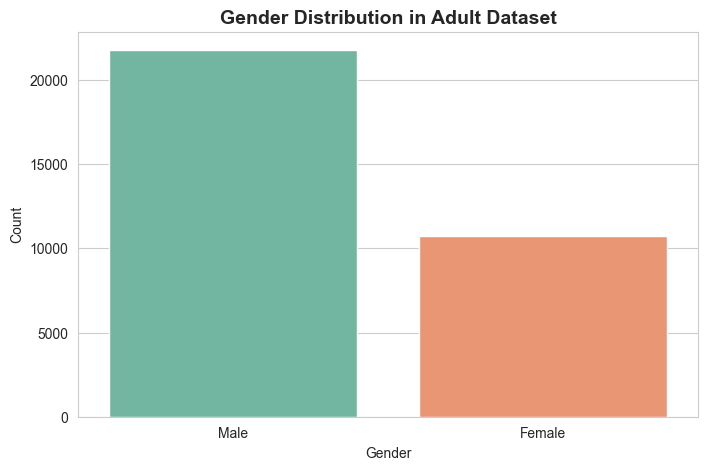

In [75]:
# Analyze Gender Distribution
print("Gender Distribution:")
print(df['sex'].value_counts())
print("\nGender Ratio (%):")
print(df['sex'].value_counts(normalize=True) * 100)

# Visualize Sex Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sex', data=df, palette='Set2')
plt.title('Gender Distribution in Adult Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

More Males are there compared to Female

# Age Distribution Analysis

Age Statistics:
count    32537.000000
mean        38.585549
std         13.637984
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

Age Range: 17 - 90


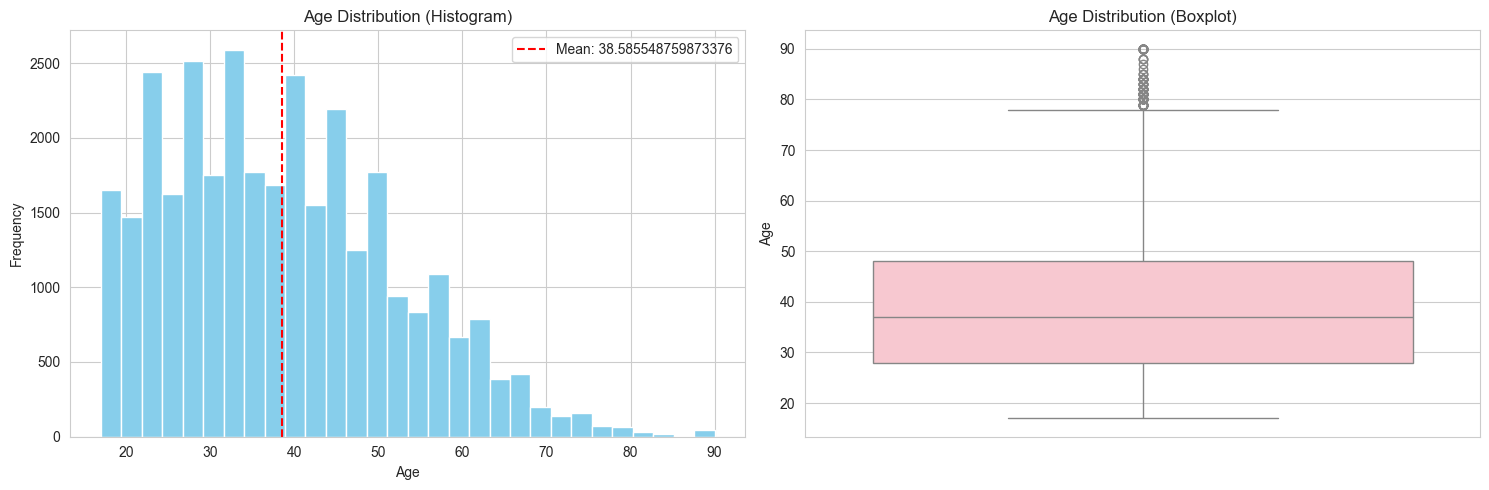

In [76]:
# Age statistics
print("Age Statistics:")
print(df['age'].describe())
print("\nAge Range:", df['age'].min(), "-", df['age'].max())

# Visualize age distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['age'], bins=30, color='skyblue')
axes[0].set_title('Age Distribution (Histogram)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean()}')
axes[0].legend()

# Boxplot
sns.boxplot(y=df['age'], ax=axes[1], color='pink')
axes[1].set_title('Age Distribution (Boxplot)')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

Histogram:
Different people with different Age groups
Younger people are working more (between the age of 25-45) years compared to old people with 50 or more years of age

Box Plot:
Older people (more than 50 years) are appearing as max outliers
while younger people are within the range 

# Income Distribution Analysis

Income Distribution:
income
<=50K    24698
>50K      7839
Name: count, dtype: int64

Income Percentage:
income
<=50K    75.907428
>50K     24.092572
Name: proportion, dtype: float64


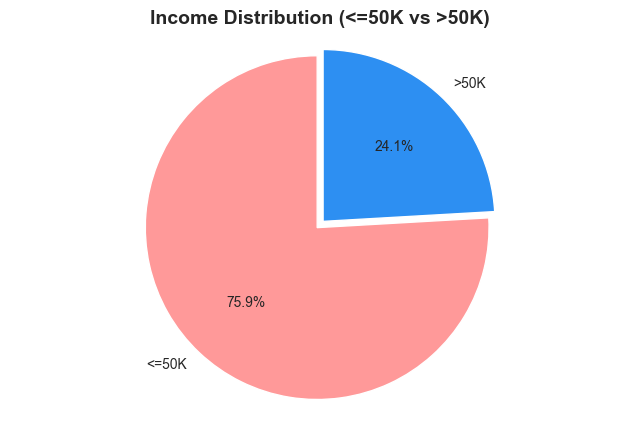

In [77]:
# Income distribution
print("Income Distribution:")
print(df['income'].value_counts())
print("\nIncome Percentage:")
print(df['income'].value_counts(normalize=True) * 100)

# Visualize income distribution
plt.figure(figsize=(8, 5))
income_counts = df['income'].value_counts()
colors = ['#ff9999', "#2d8ff2"]
plt.pie(income_counts, labels=income_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0.05, 0))
plt.title('Income Distribution (<=50K vs >50K)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

There are more number employees with less than or equal to 50k income and less number of employee with more than 50k income

# Education Level Analysis

Education Levels:
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64


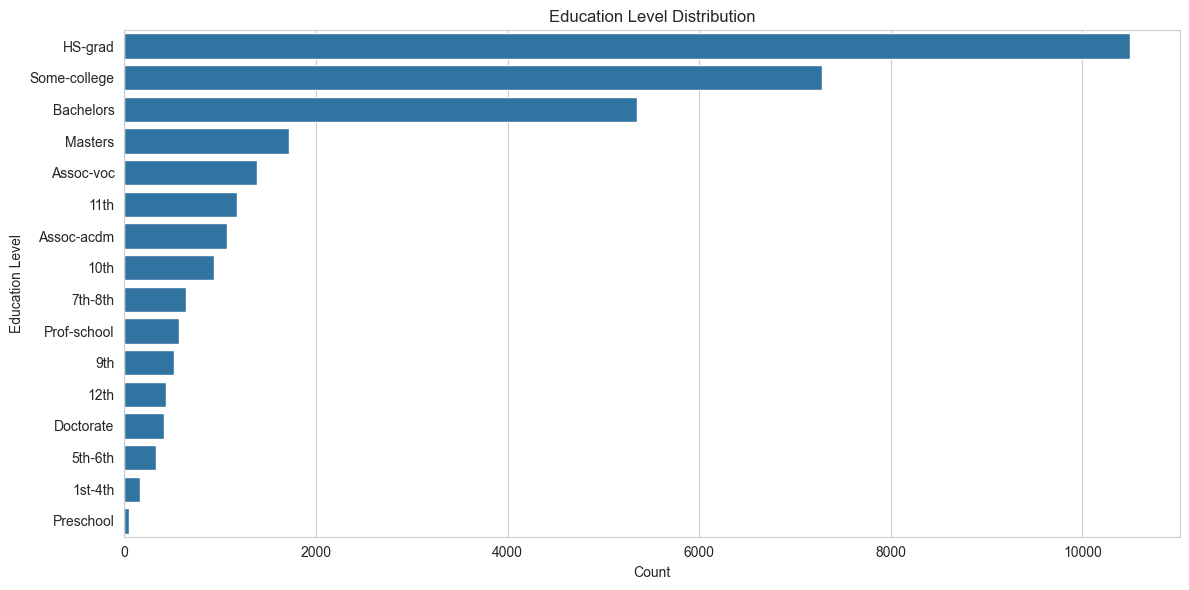

In [78]:
# Education distribution
print("Education Levels:")
print(df['education'].value_counts())

# Visualize education levels
plt.figure(figsize=(12, 6))
education_order = df['education'].value_counts().index
sns.countplot(y='education', data=df, order=education_order)
plt.title('Education Level Distribution')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

The following distribution shows the number of tional distribution where HS is the highest and Preschool is the lowest

# Work Class and Occupation Analysis

Work Class Distribution:
workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


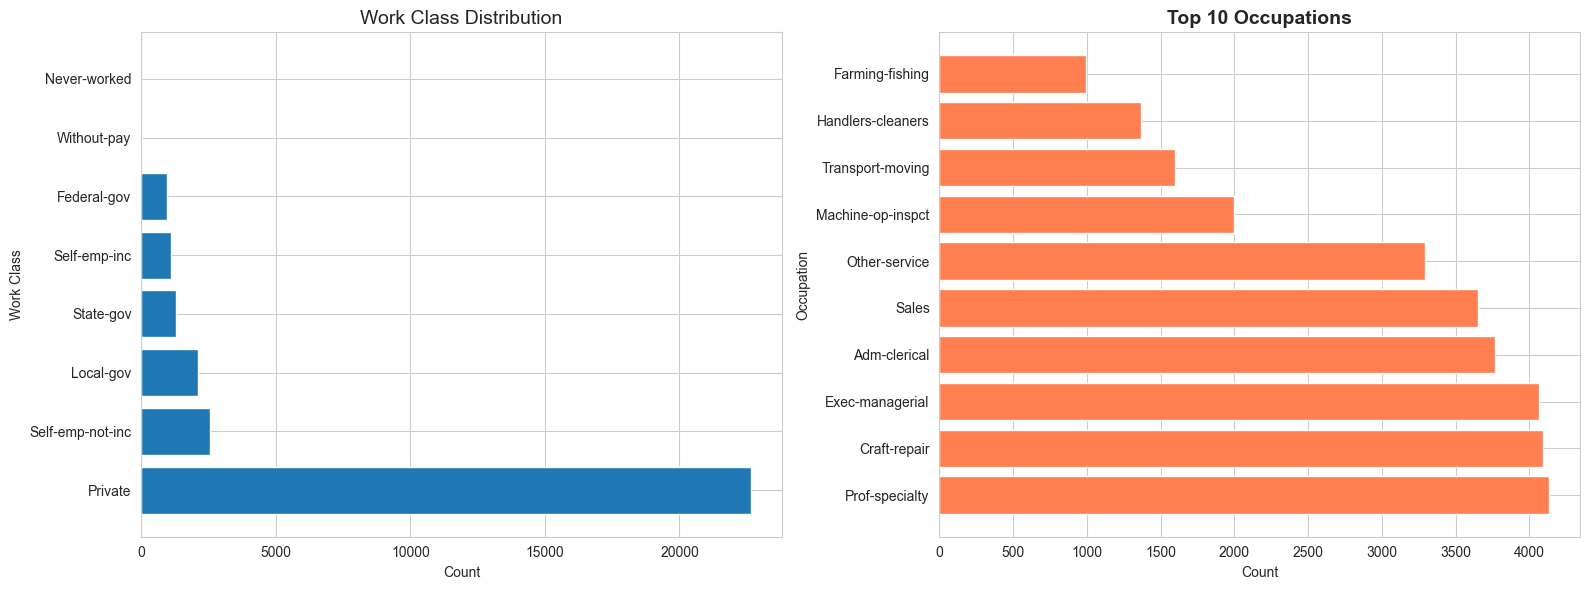

In [79]:
# Workclass analysis
print("Work Class Distribution:")
print(df['workclass'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Workclass distribution
workclass_counts = df['workclass'].value_counts()
axes[0].barh(workclass_counts.index, workclass_counts.values, )
axes[0].set_title('Work Class Distribution', fontsize=14)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Work Class')

# Top 10 occupations
occupation_counts = df['occupation'].value_counts().head(10)
axes[1].barh(occupation_counts.index, occupation_counts.values, color='coral')
axes[1].set_title('Top 10 Occupations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Occupation')

plt.tight_layout()
plt.show()

Following distribution shows the worlclasss distribution and another with occupations

# Marital Status and Relationship Analysis

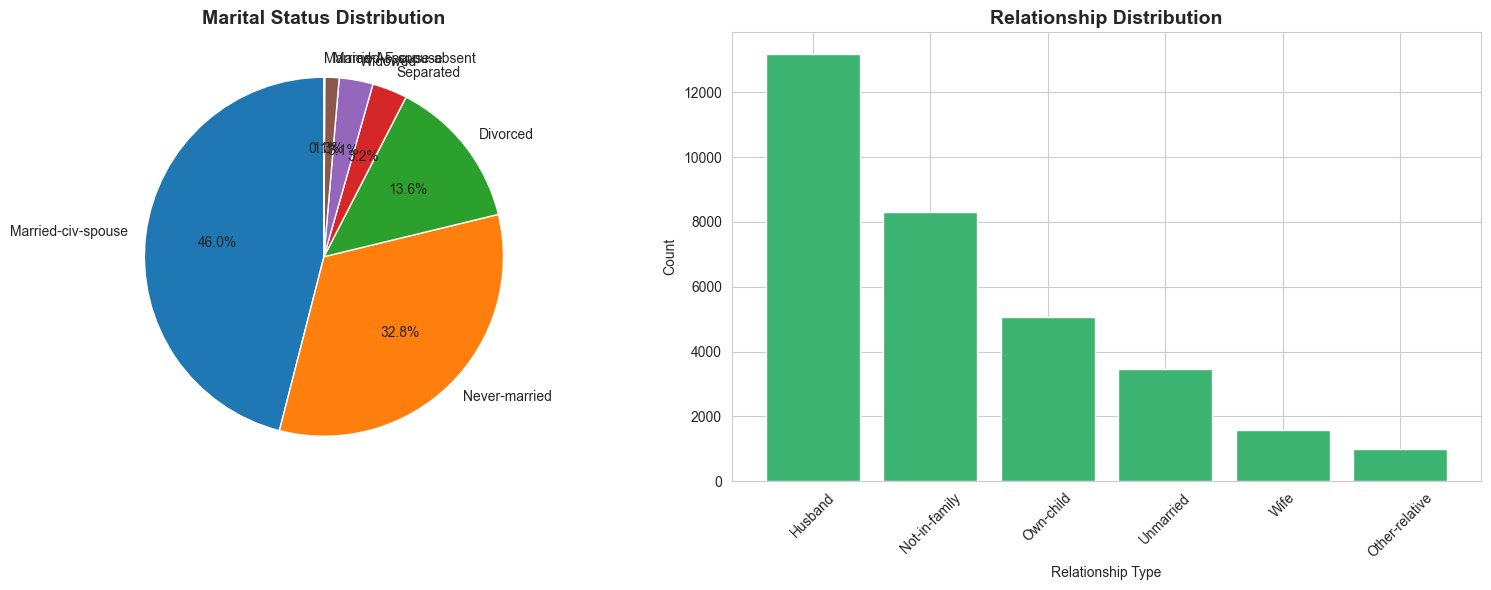

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Marital status
marital_counts = df['marital-status'].value_counts()
axes[0].pie(marital_counts, labels=marital_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Marital Status Distribution', fontsize=14, fontweight='bold')

# Relationship
relationship_counts = df['relationship'].value_counts()
axes[1].bar(relationship_counts.index, relationship_counts.values, color='mediumseagreen')
axes[1].set_title('Relationship Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Relationship Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Following pie diagram shows the distribution of martial status and another with the relationship staus

# Race Distribution Analysis

Race Distribution:
race
White                 27795
Black                  3122
Asian-Pac-Islander     1038
Amer-Indian-Eskimo      311
Other                   271
Name: count, dtype: int64


C:\Users\varun\AppData\Local\Temp\ipykernel_14716\1679974990.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='race', data=df, order=df['race'].value_counts().index, palette='Set3')


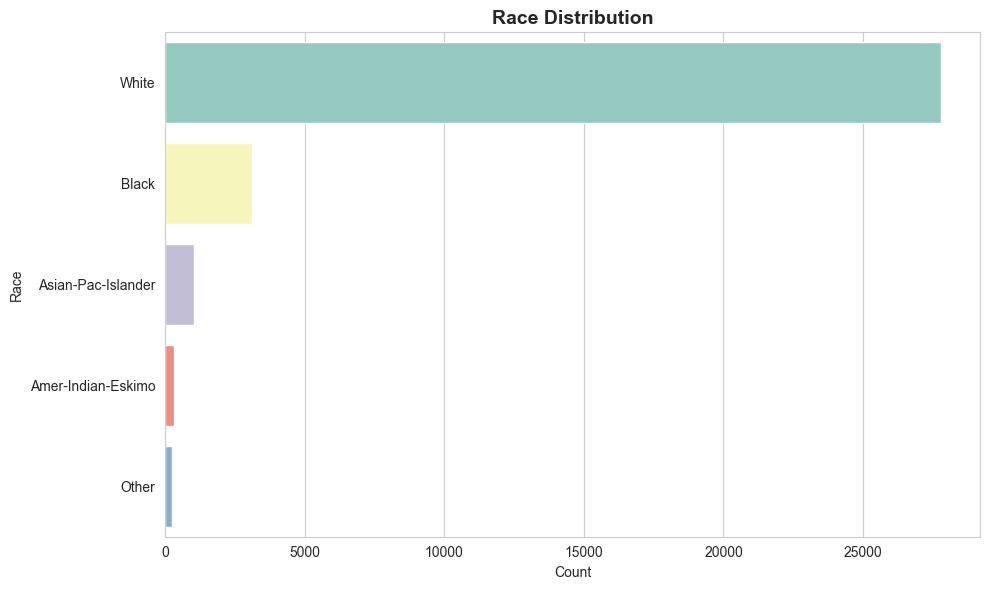

In [81]:
print("Race Distribution:")
print(df['race'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(y='race', data=df, order=df['race'].value_counts().index, palette='Set3')
plt.title('Race Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Race')
plt.tight_layout()
plt.show()

# Hours Per Week Analysis

Hours per Week Statistics:
count    32537.000000
mean        40.440329
std         12.346889
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


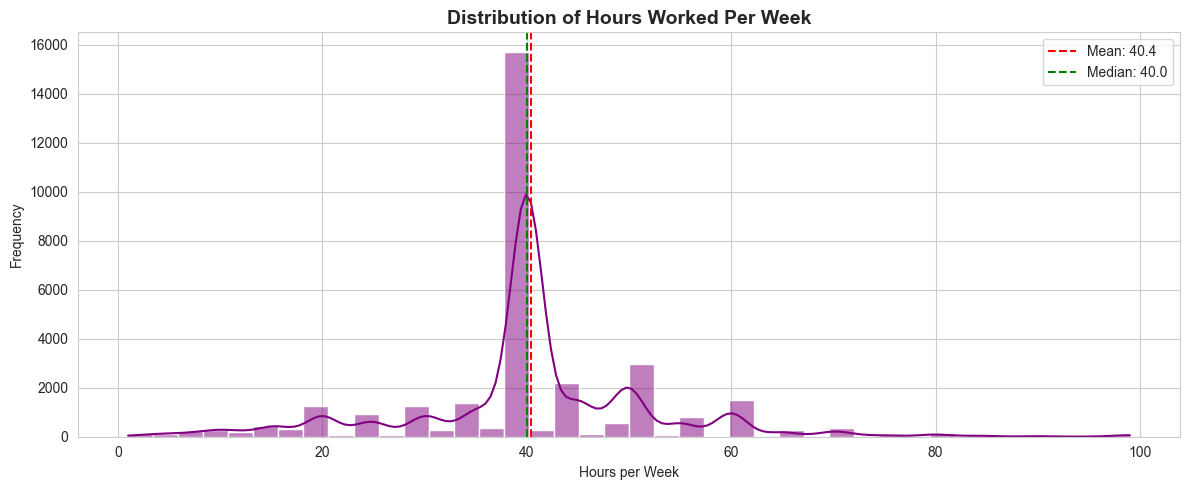

In [ ]:
print("Hours per Week Statistics:")
print(df['hours-per-week'].describe())

plt.figure(figsize=(12, 5))
sns.histplot(df['hours-per-week'], bins=40, kde=True, color='purple')
plt.title('Distribution of Hours Worked Per Week', fontsize=14, fontweight='bold')
plt.xlabel('Hours per Week')
plt.ylabel('Frequency')
plt.axvline(df['hours-per-week'].mean(), color='red', linestyle='--', label=f'Mean: {df["hours-per-week"].mean():.1f}')
plt.axvline(df['hours-per-week'].median(), color='green', linestyle='--', label=f'Median: {df["hours-per-week"].median():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

More people worked around  40 hrs per week

# Income Analysis by Demographics

C:\Users\varun\AppData\Local\Temp\ipykernel_14716\2075161724.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='income', y='age', data=df, palette='Set2')


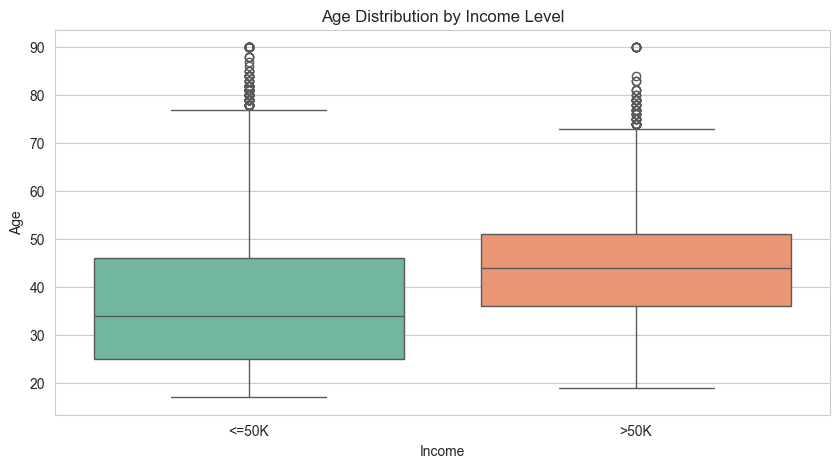

In [83]:
# Income by Age Group
plt.figure(figsize=(10, 5))
sns.boxplot(x='income', y='age', data=df, palette='Set2')
plt.title('Age Distribution by Income Level')
plt.xlabel('Income')
plt.ylabel('Age')
plt.show()

<Figure size 1000x600 with 0 Axes>

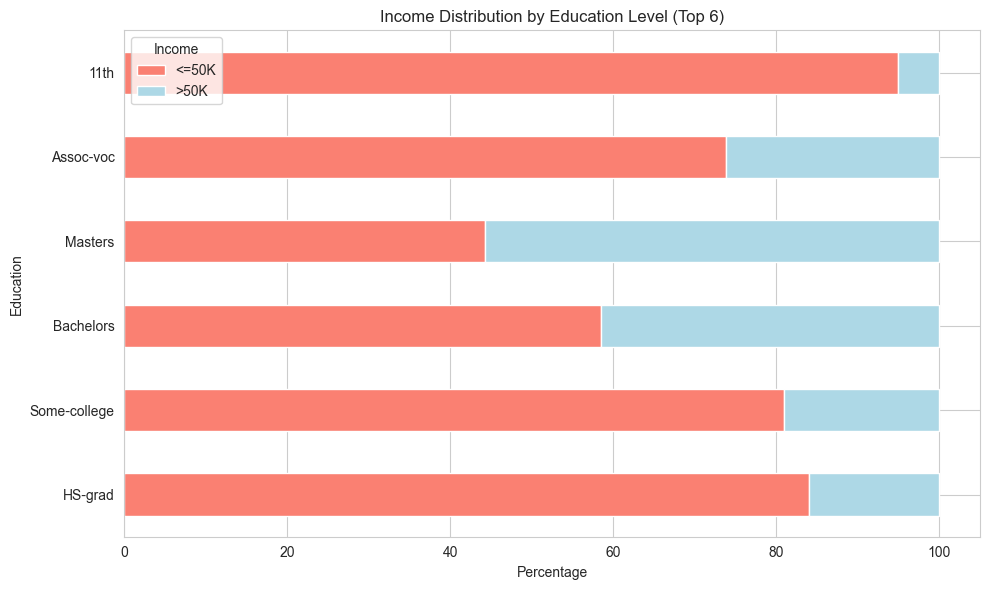

In [84]:
# Income by Education
education_income = pd.crosstab(df['education'], df['income'], normalize='index') * 100
top_education = df['education'].value_counts().head(6).index

plt.figure(figsize=(10, 6))
education_income.loc[top_education].plot(kind='barh', stacked=True, color=['salmon', 'lightblue'])
plt.title('Income Distribution by Education Level (Top 6)')
plt.xlabel('Percentage')
plt.ylabel('Education')
plt.legend(title='Income', labels=['<=50K', '>50K'])
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

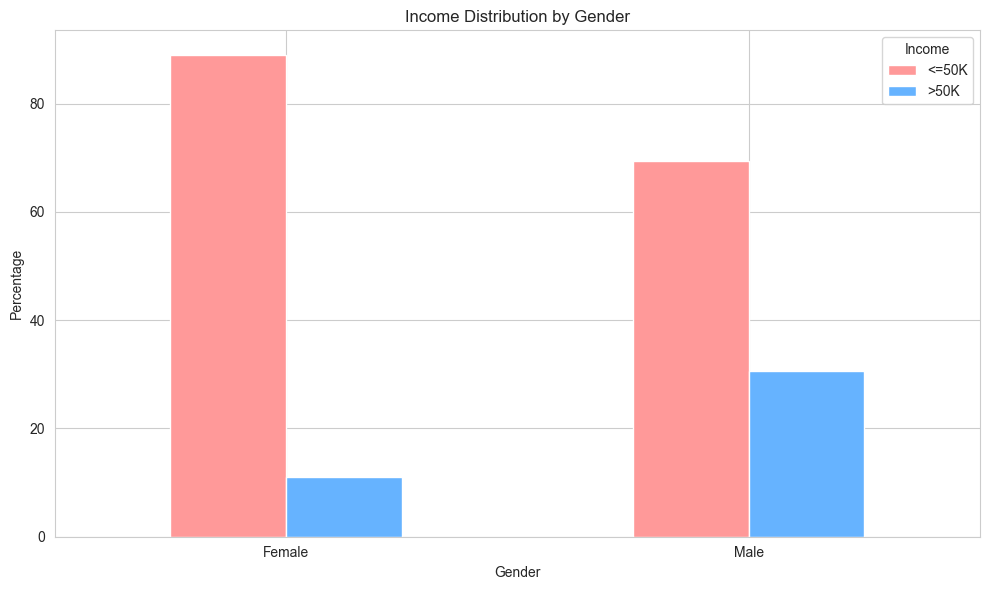

In [85]:
# Income by Gender
gender_income = pd.crosstab(df['sex'], df['income'], normalize='index') * 100

plt.figure(figsize=(8, 5))
gender_income.plot(kind='bar', color=['#ff9999', '#66b3ff'])
plt.title('Income Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.legend(title='Income', labels=['<=50K', '>50K'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary of Key Findings

In [86]:
print("="*60)
print("ADULT DATASET - KEY FINDINGS")
print("="*60)

print(f"\n1. DATASET SIZE: {df.shape[0]:,} records, {df.shape[1]} columns")

print(f"\n2. INCOME DISTRIBUTION:")
income_dist = df['income'].value_counts(normalize=True) * 100
for income, pct in income_dist.items():
    print(f"   - {income}: {pct:.1f}%")

print(f"\n3. GENDER:")
gender_dist = df['sex'].value_counts(normalize=True) * 100
for sex, pct in gender_dist.items():
    print(f"   - {sex}: {pct:.1f}%")

print(f"\n4. AGE:")
print(f"   - Average: {df['age'].mean():.1f} years")
print(f"   - Range: {df['age'].min()} - {df['age'].max()} years")

print(f"\n5. WORK HOURS:")
print(f"   - Average: {df['hours-per-week'].mean():.1f} hours/week")

print(f"\n6. EDUCATION:")
print(f"   - Most common: {df['education'].value_counts().index[0]}")

print(f"\n7. OCCUPATION:")
print(f"   - Most common: {df['occupation'].value_counts().index[0]}")

print("\n" + "="*60)

ADULT DATASET - KEY FINDINGS

1. DATASET SIZE: 32,537 records, 15 columns

2. INCOME DISTRIBUTION:
   - <=50K: 75.9%
   - >50K: 24.1%

3. GENDER:
   - Male: 66.9%
   - Female: 33.1%

4. AGE:
   - Average: 38.6 years
   - Range: 17 - 90 years

5. WORK HOURS:
   - Average: 40.4 hours/week

6. EDUCATION:
   - Most common: HS-grad

7. OCCUPATION:
   - Most common: Prof-specialty

